# Hybrid Biomedical Image-Analysis Pipeline — Cell Nuclei

A local, auditable pipeline that moves a biomedical image through several stages and produces a **structured, checkable record** rather than a free-text guess.

```
raw image → segmentation → quantitative region features
          → structured JSON record → short narrative
```

It combines three method families: **Qwen2.5-VL** as the local multimodal model, classical image processing (**scikit-image**), and a small **U-Net** (PyTorch).

**Modality:** synthetic fluorescence-microscopy cell nuclei (DAPI-like blue nuclei on a dark field), 256×256, with train/val/test splits and binary masks.

> Educational use only — none of these models are cleared for clinical use.
> LLM outputs can hallucinate; structured numerical JSON is kept as the source of truth for the quantitative pipeline.

### How this notebook is organised
- **Task 1** — data preparation, EDA, and Qwen2.5-VL direct image description
- **Task 2** — classical features (Otsu → regionprops) → numbers-first Qwen2.5-VL
- **Task 3** — train a small U-Net, evaluate Dice/IoU
- **Task 4** — hybrid pipeline → per-image JSON → aggregated CSV

**Model choice:** the assignment guidance permits Qwen2.5-VL as an alternative to Qwen/Qwen2.5-VL-3B-Instruct when the latter has the `mllama` architecture problem. This notebook therefore uses `Qwen/Qwen2.5-VL-3B-Instruct` locally through Hugging Face Transformers and does not require local Qwen2.5-VL.


## 0. Setup

Install the imaging/ML libraries, import everything, and fix a few constants.
`torch` and `scikit-image` are usually already present on Colab; on a local
machine the pip line installs whatever's missing.

In [12]:
# On a fresh environment, uncomment to install:
# !pip install -q numpy pandas matplotlib scikit-image scikit-learn torch requests

import warnings
warnings.filterwarnings("ignore")

import os, json, base64, re, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage import io, color, transform, img_as_ubyte
from skimage.filters import threshold_otsu
from skimage.morphology import (remove_small_objects, remove_small_holes,
                                disk, binary_opening)
from skimage.measure import label, regionprops_table

import requests

# Qwen2.5-VL imports are intentionally loaded in the dedicated setup cell below,
# AFTER the required packages have been installed. This avoids the common Colab
# problem where an old Transformers version is imported before pip upgrades it.
Qwen2_5_VLForConditionalGeneration = None
AutoProcessor = None
process_vision_info = None

plt.rcParams["figure.figsize"] = (10, 4)

### Constants

`DATA_DIR` points to the downloaded dataset. The multimodal model used throughout the LLM stages is the permitted Qwen2.5-VL alternative.


In [13]:
# ---- paths ----
DATA_DIR = Path("nuclei_dataset")
OUT = Path("outputs"); FIG = OUT / "figures"; REC = OUT / "records"
MODELS = Path("models")
for d in (FIG, REC, MODELS):
    d.mkdir(parents=True, exist_ok=True)
IMG_SIZE = 256
VLM_MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"
TEXT_MODEL = VLM_MODEL
QWEN_READY = False
qwen_model = None
qwen_processor = None
SEED = 42
EPOCHS = 30
BATCH = 4
LR = 1e-3
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


### (Optional) Download the dataset

If you're on Colab or a clean machine, this cell fetches and unpacks the
dataset. Skip it if you already have `nuclei_dataset/` locally.

In [14]:
DATASET_URL = ("https://codeload.github.com/Nickolay-K/"
               "Assingnment-3-dataset/tar.gz/refs/heads/main")

if not DATA_DIR.exists():
    import urllib.request, tarfile, zipfile, tempfile
    print("Downloading dataset...")
    tmp = tempfile.mkdtemp()
    tar_path = os.path.join(tmp, "ds.tar.gz")
    urllib.request.urlretrieve(DATASET_URL, tar_path)
    with tarfile.open(tar_path) as t:
        t.extractall(tmp)
    # the archive contains nuclei_dataset.zip
    inner = None
    for root, _, files in os.walk(tmp):
        for f in files:
            if f.endswith(".zip"):
                inner = os.path.join(root, f)
    with zipfile.ZipFile(inner) as z:
        z.extractall(".")
    print("Extracted to", DATA_DIR.resolve())
else:
    print("Dataset already present at", DATA_DIR.resolve())

Dataset already present at /content/nuclei_dataset


## Task 1 — Data preparation and EDA

Load the images, convert to grayscale, resize to a common 256×256 (they're
already that size, but we keep the step so the code is modality-agnostic), and
produce a small EDA: a montage of samples and a pooled intensity histogram.

In [15]:
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

def load_grayscale(path, size=IMG_SIZE):
    """Load one image as grayscale float in [0,1], resized to size×size."""
    img = io.imread(path)
    if img.ndim == 3:
        if img.shape[2] == 4:
            img = color.rgba2rgb(img)
        img = color.rgb2gray(img)
    else:
        img = img.astype(np.float64)
        if img.max() > 1.0:
            img = img / img.max()
    img = transform.resize(img, (size, size), anti_aliasing=True)
    return np.clip(img, 0.0, 1.0)


def find_split_dir(split):
    """Return the folder for a split, tolerating nuclei_dataset/ nesting."""
    for c in (DATA_DIR / split, DATA_DIR / "nuclei_dataset" / split):
        if c.is_dir():
            return c
    raise FileNotFoundError(f"Split '{split}' not found under {DATA_DIR}")


def load_split(split, size=IMG_SIZE):
    """Load matched (image, mask) pairs for a split -> (imgs, masks, ids)."""
    sdir = find_split_dir(split)
    img_dir, mask_dir = sdir / "images", sdir / "masks"
    imgs, masks, ids = [], [], []
    for p in sorted(img_dir.glob("*.png")):
        mp = mask_dir / p.name
        if not mp.exists():
            continue
        imgs.append(load_grayscale(p, size))
        masks.append((load_grayscale(mp, size) > 0.5).astype(np.float32))
        ids.append(p.stem)
    print(f"{split}: {len(imgs)} image/mask pairs")
    return np.stack(imgs), np.stack(masks), ids

In [16]:
# Load the three splits
train_imgs, train_masks, train_ids = load_split("train")
val_imgs,   val_masks,   val_ids   = load_split("val")
test_imgs,  test_masks,  test_ids  = load_split("test")

train: 80 image/mask pairs
val: 20 image/mask pairs
test: 12 image/mask pairs


### EDA — sample montage and intensity histogram

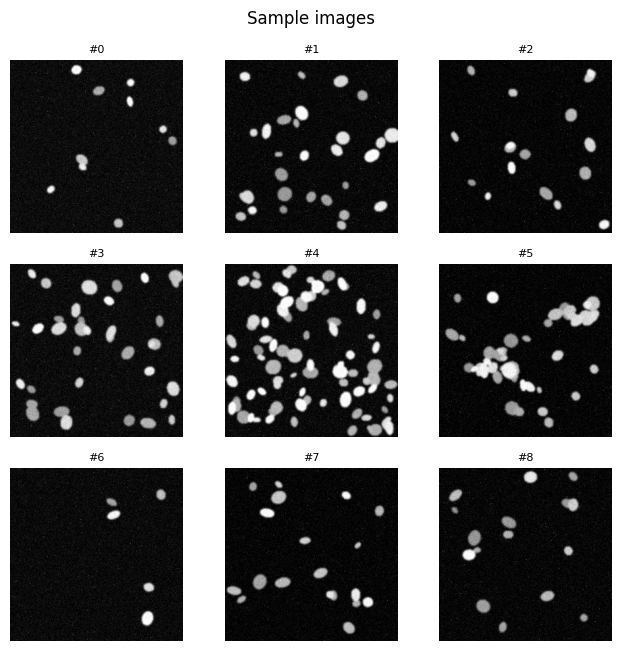

In [17]:
def show_montage(imgs, n=9, title="Sample images", save=None):
    n = min(n, len(imgs)); cols = int(np.ceil(np.sqrt(n))); rows = int(np.ceil(n/cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    ax = np.atleast_1d(ax).ravel()
    for i in range(len(ax)):
        ax[i].axis("off")
        if i < n:
            ax[i].imshow(imgs[i], cmap="gray"); ax[i].set_title(f"#{i}", fontsize=8)
    fig.suptitle(title); fig.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

show_montage(train_imgs, n=9, save=FIG / "eda_montage.png")

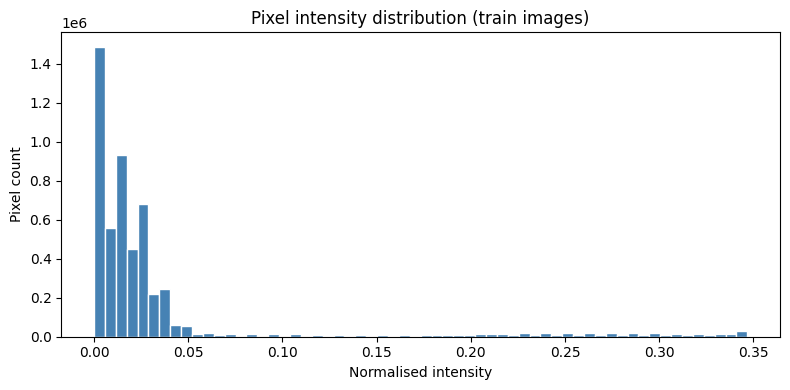

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(train_imgs.ravel(), bins=60, color="steelblue", edgecolor="white")
plt.title("Pixel intensity distribution (train images)")
plt.xlabel("Normalised intensity"); plt.ylabel("Pixel count")
plt.tight_layout(); plt.savefig(FIG / "eda_histogram.png", dpi=150); plt.show()

The histogram is strongly skewed toward dark values — most of each image
is background, with a small bright foreground (the nuclei). That heavy
background is exactly the regime a global threshold like Otsu is designed for,
which motivates Task 2.

### Ground-truth answer key

The dataset ships a `metadata.csv` giving the true `n_objects`, `density`, and
intensity per image. We'll use it later to score our pipeline against truth.

In [19]:
def load_metadata():
    for base in (DATA_DIR, DATA_DIR / "nuclei_dataset"):
        p = base / "metadata.csv"
        if p.exists():
            return pd.read_csv(p)
    return None

meta = load_metadata()
meta.head() if meta is not None else print("metadata.csv not found")

,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


### Qwen2.5-VL local model setup

The assignment guidance permits **Qwen2.5-VL** as an alternative vision model when `llama3.2-vision` has the `mllama` architecture issue. This notebook therefore loads `Qwen/Qwen2.5-VL-3B-Instruct` locally with Hugging Face Transformers; **Ollama is not required**.

On Colab, a GPU runtime (for example T4) is strongly recommended.


In [20]:
# Install and import Qwen2.5-VL AFTER installation.
# This ordering is important in Colab: importing Transformers before upgrading it
# can leave the old module in memory and cause Qwen2_5_VLForConditionalGeneration
# to be unavailable.
%pip -q install -U "transformers>=4.49.0" accelerate qwen-vl-utils

# Fresh imports after installation
import importlib, transformers
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

print("Transformers version:", transformers.__version__)
print("Qwen2.5-VL classes imported successfully.")


Transformers version: 5.15.0
Qwen2.5-VL classes imported successfully.


In [11]:
def extract_json(text):
    """Extract the first JSON object from a model response without raising."""
    if text is None:
        return {"_parse_error": True, "_raw": ""}
    cleaned = re.sub(r"^```(?:json)?|```$", "", str(text).strip(), flags=re.MULTILINE).strip()
    m = re.search(r"\{.*\}", cleaned, flags=re.DOTALL)
    if not m:
        return {"_parse_error": True, "_raw": cleaned}
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return {"_parse_error": True, "_raw": cleaned}


def load_qwen_model():
    """Load Qwen2.5-VL directly on the Colab GPU without CPU/disk offloading."""
    global qwen_model, qwen_processor, QWEN_READY

    if QWEN_READY:
        return qwen_model, qwen_processor

    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA GPU is required for Qwen2.5-VL. In Colab choose "
            "Runtime -> Change runtime type -> T4 GPU, restart the runtime, and Run all."
        )

    dtype = torch.float16
    print(f"Loading {VLM_MODEL} directly on GPU 0 (no CPU/disk offloading)...")

    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        VLM_MODEL,
        torch_dtype=dtype,
        device_map={"": 0},
        low_cpu_mem_usage=True
    )

    qwen_processor = AutoProcessor.from_pretrained(
        VLM_MODEL,
        min_pixels=256 * 256,
        max_pixels=512 * 512
    )

    qwen_model.eval()
    QWEN_READY = True
    print("Qwen2.5-VL loaded successfully on GPU without CPU/disk offloading.")
    return qwen_model, qwen_processor


def _qwen_generate(prompt, image_path=None, temperature=0.2, max_new_tokens=128):
    """Run Qwen2.5-VL locally with compact visual inputs and short generation."""
    model, processor = load_qwen_model()

    if image_path is not None:
        messages = [{"role": "user", "content": [
            {"type": "image", "image": str(image_path)},
            {"type": "text", "text": prompt}
        ]}]
    else:
        messages = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    # Model is entirely on GPU 0, so inputs go to CUDA directly.
    inputs = {
        k: v.to("cuda") if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    do_sample = temperature > 0
    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample
    }
    if do_sample:
        gen_kwargs.update({"temperature": temperature, "top_p": 0.9})

    with torch.inference_mode():
        generated_ids = model.generate(**inputs, **gen_kwargs)

    input_len = inputs["input_ids"].shape[1]
    generated_ids_trimmed = [
        out_ids[input_len:] for out_ids in generated_ids
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()
    return output_text

print("Qwen2.5-VL target:", VLM_MODEL)

# Explicit setup check.
load_qwen_model()


Qwen2.5-VL target: Qwen/Qwen2.5-VL-3B-Instruct
Loading Qwen/Qwen2.5-VL-3B-Instruct directly on GPU 0 (no CPU/disk offloading)...


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen2.5-VL loaded successfully on GPU without CPU/disk offloading.


(Qwen2_5_VLForConditionalGeneration(
   (model): Qwen2_5_VLModel(
     (visual): Qwen2_5_VisionTransformerPretrainedModel(
       (patch_embed): Qwen2_5_VisionPatchEmbed(
         (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
       )
       (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
       (blocks): ModuleList(
         (0-31): 32 x Qwen2_5_VLVisionBlock(
           (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
           (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
           (attn): Qwen2_5_VLVisionAttention(
             (qkv): Linear(in_features=1280, out_features=3840, bias=True)
             (proj): Linear(in_features=1280, out_features=1280, bias=True)
           )
           (mlp): Qwen2_5_VLMLP(
             (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
             (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
             (down_proj): Linear(in_features=3420, out_features=1280, bias=True)

### Prompts

The optimised prompts must appear in your report. They anchor the model as
**descriptive, not diagnostic**, force strict JSON, and allow `"uncertain"` so
the model isn't pushed into guessing (this is central to the hallucination
question).

In [21]:
NAIVE_VLM_PROMPT = "What is in this medical image?"

OPTIMISED_VLM_PROMPT = """You are assisting with an educational image-DESCRIPTION task.
You are NOT a diagnostic tool and must not diagnose disease, malignancy, or name medical conditions.

Describe only visually observable information. Do not infer a diagnosis. Focus on the
imaging modality if visually evident, visible tissue/structures, prominent shapes/textures/regions,
contrast, and overall image quality. If a field cannot be determined confidently, use exactly
"uncertain" rather than guessing.

Return ONLY one valid JSON object with exactly these four keys and no markdown:
{
  "modality": "<modality or uncertain>",
  "tissue_type": "<visible tissue/structure or uncertain>",
  "notable_features": "<short non-diagnostic visual description or uncertain>",
  "image_quality": "<good | moderate | poor | uncertain>"
}
"""

OPTIMISED_TEXT_PROMPT = """You are assisting with an educational image-DESCRIPTION task.
You receive ONLY numerical summary statistics from an automated segmentation and cannot see the image.
Do not diagnose and do not invent information that is not supported by the numbers.

Return ONLY one valid JSON object with exactly these keys:
{
  "n_objects": <integer>,
  "density_class": "<none | sparse | moderate | dense>",
  "shape_regularity": "<regular | irregular | mixed | uncertain>",
  "quality_flag": "<ok | check | uncertain>",
  "narrative": "<one short numbers-grounded paragraph>"
}
If the numbers are insufficient for a field, use "uncertain".

Numeric summary:
"""


### VLM description + repeatability

Send one representative image to Qwen2.5-VL with the naive prompt and the optimised
prompt, then repeat the optimised prompt five times to assess whether the structured
outputs are identical across runs.


In [22]:
def describe_image_vlm(gray_img, prompt, temperature=0.2, max_new_tokens=128):
    """Save a representative image and send it to local Qwen2.5-VL."""
    tmp = FIG / "_vlm_input.png"
    io.imsave(tmp, img_as_ubyte(gray_img))

    raw = _qwen_generate(
        prompt,
        image_path=tmp,
        temperature=temperature,
        max_new_tokens=max_new_tokens
    )

    try:
        out = extract_json(raw)
    except Exception:
        out = {}

    required_defaults = {
        "modality": "uncertain",
        "tissue_type": "uncertain",
        "notable_features": "uncertain",
        "image_quality": "uncertain"
    }

    for key, default in required_defaults.items():
        if key not in out or out[key] in [None, ""]:
            out[key] = default

    out["_raw"] = raw
    return out

if "test_imgs" not in globals():
    raise RuntimeError(
        "test_imgs is not defined. Run the Task 1 data-preparation cell "
        "above first; it creates grayscale 256 x 256 train/val/test arrays."
    )

if len(test_imgs) == 0:
    raise RuntimeError("test_imgs is empty. Check the dataset and preprocessing cells.")

rep_img = np.asarray(test_imgs[0], dtype=np.float32)

if rep_img.ndim == 3 and rep_img.shape[-1] in (3, 4):
    rep_img = color.rgb2gray(rep_img[..., :3])

if rep_img.shape != (256, 256):
    rep_img = transform.resize(rep_img, (256, 256), anti_aliasing=True)

rep_img = np.clip(rep_img, 0.0, 1.0).astype(np.float32)
io.imsave(FIG / "representative_image.png", img_as_ubyte(rep_img))

print("Representative image shape:", rep_img.shape)
print("Vision model:", VLM_MODEL)

print("\nRunning naive prompt...")
naive = describe_image_vlm(
    rep_img, NAIVE_VLM_PROMPT, temperature=0.2, max_new_tokens=128
)

print("\nNAIVE:", {k: v for k, v in naive.items() if not k.startswith("_")})

print("\nRunning optimised prompt...")
opt = describe_image_vlm(
    rep_img, OPTIMISED_VLM_PROMPT, temperature=0.2, max_new_tokens=128
)

print("\nOPTIMISED:", {k: v for k, v in opt.items() if not k.startswith("_")})

REQUIRED_VLM_KEYS = {
    "modality", "tissue_type", "notable_features", "image_quality"
}

def validate_vlm_record(record, name):
    missing = REQUIRED_VLM_KEYS - set(record.keys())
    if missing:
        print(f"WARNING: {name} is missing keys: {sorted(missing)}")
        return False
    print(f"{name}: all required JSON fields present.")
    return True

naive_valid = validate_vlm_record(naive, "NAIVE")
opt_valid = validate_vlm_record(opt, "OPTIMISED")


repeat_runs = []
print("\nRepeatability (same image, 5 runs):")

for i in range(5):
    r = describe_image_vlm(
        rep_img,
        OPTIMISED_VLM_PROMPT,
        temperature=0.7,
        max_new_tokens=128
    )
    repeat_runs.append(r)
    print(
        f"Run {i + 1}:",
        {k: v for k, v in r.items() if not k.startswith("_")}
    )

repeat_json = [
    json.dumps(
        {k: v for k, v in r.items() if not k.startswith("_")},
        sort_keys=True,
        ensure_ascii=False
    )
    for r in repeat_runs
]

unique_runs = len(set(repeat_json))
observed_variation = unique_runs > 1

print(f"\nUnique structured outputs: {unique_runs}/5")
print("Observed run-to-run variation:", observed_variation)


with open(REC / "task1_vlm_comparison.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": VLM_MODEL,
            "naive": naive,
            "optimised": opt,
            "naive_valid": naive_valid,
            "optimised_valid": opt_valid,
            "repeated_runs": repeat_runs,
            "unique_runs": unique_runs,
            "observed_variation": observed_variation
        },
        f,
        indent=2,
        ensure_ascii=False
    )

print("\nTask 1 VLM comparison saved to:", REC / "task1_vlm_comparison.json")


Representative image shape: (256, 256)
Vision model: Qwen/Qwen2.5-VL-3B-Instruct

Running naive prompt...
Loading Qwen/Qwen2.5-VL-3B-Instruct directly on GPU 0 (no CPU/disk offloading)...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Qwen2.5-VL loaded successfully on GPU without CPU/disk offloading.

NAIVE: {'modality': 'uncertain', 'tissue_type': 'uncertain', 'notable_features': 'uncertain', 'image_quality': 'uncertain'}

Running optimised prompt...

OPTIMISED: {'modality': 'uncertain', 'tissue_type': 'uncertain', 'notable_features': 'Several bright, round objects scattered across a dark background.', 'image_quality': 'poor'}
NAIVE: all required JSON fields present.
OPTIMISED: all required JSON fields present.

Repeatability (same image, 5 runs):
Run 1: {'modality': 'uncertain', 'tissue_type': 'uncertain', 'notable_features': 'Unclear shape and texture; possibly small round or oval structures in a dark background.', 'image_quality': 'poor'}
Run 2: {'modality': 'uncertain', 'tissue_type': 'uncertain', 'notable_features': 'Bright, round, and oval shapes scattered across a dark background.', 'image_quality': 'poor'}
Run 3: {'modality': 'uncertain', 'tissue_type': 'uncertain', 'notable_features': 'Several bright spots

## Task 2 — Classical features and numbers-first interpretation

Otsu threshold → morphological cleanup → connected components → per-object
feature table. The table is collapsed to a **numbers-only** summary that the
text LLM interprets *without ever seeing the image* — so any description it
gives is grounded purely in measurements.

In [23]:
REGION_PROPS = ("label", "area", "eccentricity", "solidity", "extent",
                "perimeter", "mean_intensity", "major_axis_length",
                "minor_axis_length")

def segment_otsu(gray, min_size=64):
    """Otsu threshold + morphological cleanup -> boolean foreground mask."""
    mask = gray > threshold_otsu(gray)
    if mask.mean() > 0.5:          # foreground should be the minority class
        mask = ~mask
    mask = binary_opening(mask, disk(1))
    mask = remove_small_objects(mask, min_size=min_size)
    mask = remove_small_holes(mask, area_threshold=min_size)
    return mask

def region_table(gray, mask):
    lab = label(mask)
    if lab.max() == 0:
        return pd.DataFrame(columns=REGION_PROPS)
    return pd.DataFrame(regionprops_table(lab, intensity_image=gray,
                                          properties=REGION_PROPS))

def summarise(df):
    if len(df) == 0:
        return {"n_objects": 0}
    return {
        "n_objects": int(len(df)),
        "mean_area": float(df["area"].mean()),
        "min_area": float(df["area"].min()),
        "max_area": float(df["area"].max()),
        "std_area": float(df["area"].std(ddof=0)),
        "mean_eccentricity": float(df["eccentricity"].mean()),
        "mean_solidity": float(df["solidity"].mean()),
        "mean_intensity": float(df["mean_intensity"].mean()),
    }

def summary_sentence(s, image_id="image"):
    if s.get("n_objects", 0) == 0:
        return f"In {image_id}, segmentation detected no distinct objects."
    return (f"In {image_id}, segmentation detected {s['n_objects']} objects. "
            f"Areas range {s['min_area']:.0f}-{s['max_area']:.0f} px "
            f"(mean {s['mean_area']:.0f}, sd {s['std_area']:.0f}). "
            f"Mean eccentricity {s['mean_eccentricity']:.2f} (0=circular, 1=elongated), "
            f"mean solidity {s['mean_solidity']:.2f} (1=convex). "
            f"Mean intensity {s['mean_intensity']:.2f} on 0-1.")

def density_class(s, small=5, many=20):
    n = s.get("n_objects", 0)
    return "none" if n == 0 else "sparse" if n < small else "moderate" if n < many else "dense"

In representative, segmentation detected 7 objects. Areas range 120-428 px (mean 215, sd 96). Mean eccentricity 0.61 (0=circular, 1=elongated), mean solidity 0.96 (1=convex). Mean intensity 0.22 on 0-1.


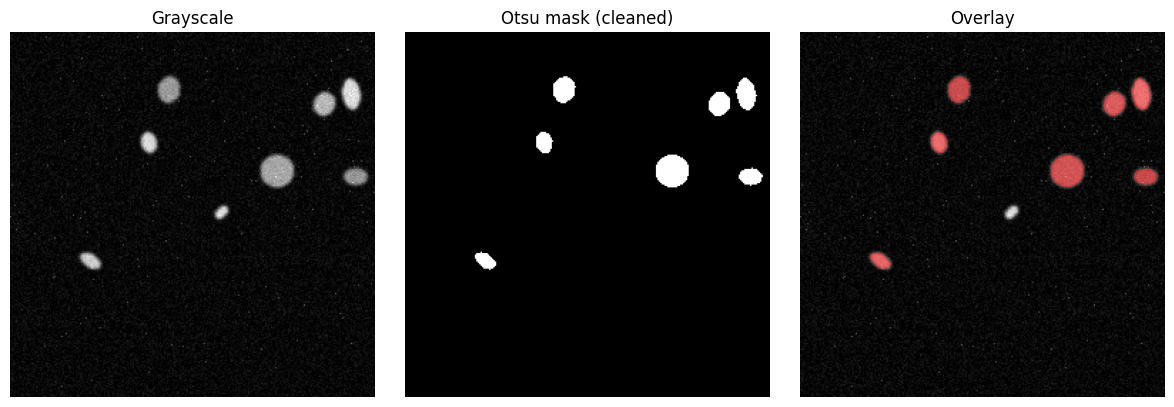

,label,area,eccentricity,solidity,extent,perimeter,mean_intensity,major_axis_length,minor_axis_length
0,1,228.0,0.552340,0.962025,0.750000,54.284271,0.191318,18.676576,15.569152
1,2,235.0,0.806658,0.947581,0.681159,58.526912,0.257473,22.532446,13.317094
2,3,203.0,0.501259,0.990244,0.796078,49.455844,0.221809,17.278318,14.950886
3,4,138.0,0.661944,0.958333,0.766667,41.798990,0.244930,15.316293,11.480371
4,5,428.0,0.197127,0.972727,0.809074,73.941125,0.211137,23.571014,23.108501


In [24]:
# Run the classical path on the representative image and visualise it
mask = segment_otsu(rep_img)
tbl  = region_table(rep_img, mask)
summ = summarise(tbl)
sent = summary_sentence(summ, "representative")
print(sent)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rep_img, cmap="gray"); ax[0].set_title("Grayscale")
ax[1].imshow(mask, cmap="gray");    ax[1].set_title("Otsu mask (cleaned)")
ax[2].imshow(rep_img, cmap="gray")
ax[2].imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.5)
ax[2].set_title("Overlay")
for a in ax: a.axis("off")
plt.tight_layout(); plt.savefig(FIG / "classical_representative.png", dpi=150); plt.show()
tbl.head()

### Numbers-first LLM description

The text model sees only `sent` (numbers), never the image.

In [25]:
def describe_numbers(sentence, temperature=0.2):
    """Numbers-first Qwen2.5-VL call: text only, no image is supplied."""
    raw = _qwen_generate(OPTIMISED_TEXT_PROMPT + sentence, image_path=None,
                          temperature=temperature, max_new_tokens=300)
    out = extract_json(raw)
    out["_raw"] = raw
    return out

text_desc = describe_numbers(sent, temperature=0.2)
print("Numbers-first JSON:", {k:v for k,v in text_desc.items() if not k.startswith("_")})


Numbers-first JSON: {'n_objects': 7, 'density_class': 'dense', 'shape_regularity': 'irregular', 'quality_flag': 'check', 'narrative': 'The segmentation detected 7 objects with areas ranging from 120 to 428 pixels, having a mean area of 215 pixels with a standard deviation of 96. The mean eccentricity is 0.61, indicating some elongation, while the mean solidity is 0.96, suggesting a high degree of convexity. The mean intensity is 0.22, which is relatively low.'}


## Task 3 — U-Net segmentation

A compact 3-level U-Net trained on the binary masks. We track train/val loss and
validation Dice/IoU per epoch, then show input / ground-truth / prediction
panels for several validation images.

In [26]:
class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        self.d1, self.d2, self.d3 = DoubleConv(in_ch, base), DoubleConv(base, base*2), DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*4, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2); self.u3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2); self.u2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base,  2, stride=2);  self.u1 = DoubleConv(base*2, base)
        self.out = nn.Conv2d(base, out_ch, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.bottleneck(self.pool(c3))
        x = self.u3(torch.cat([self.up3(b), c3], 1))
        x = self.u2(torch.cat([self.up2(x), c2], 1))
        x = self.u1(torch.cat([self.up1(x), c1], 1))
        return self.out(x)

class SegDS(Dataset):
    def __init__(self, imgs, masks):
        self.imgs = imgs.astype(np.float32); self.masks = masks.astype(np.float32)
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        return (torch.from_numpy(self.imgs[i]).unsqueeze(0),
                torch.from_numpy(self.masks[i]).unsqueeze(0))

In [27]:
def dice_loss(logits, targets, eps=1e-6):
    p = torch.sigmoid(logits)
    num = 2*(p*targets).sum((1,2,3)); den = p.sum((1,2,3))+targets.sum((1,2,3))+eps
    return (1 - num/den).mean()

def bce_dice(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets) + dice_loss(logits, targets)

@torch.no_grad()
def dice_iou(logits, targets, thr=0.5, eps=1e-6):
    pred = (torch.sigmoid(logits) > thr).float()
    inter = (pred*targets).sum((1,2,3)); ps = pred.sum((1,2,3)); ts = targets.sum((1,2,3))
    dice = (2*inter+eps)/(ps+ts+eps); iou = (inter+eps)/(ps+ts-inter+eps)
    return dice.mean().item(), iou.mean().item()

Choose the loss here. The extension task asks you to compare **BCE vs Dice
vs BCE+Dice** — swap `loss_fn` and re-run to fill that table.

In [28]:
def train_unet(train_ds, val_ds, epochs=EPOCHS, batch=BATCH, lr=LR, loss_fn=bce_dice):
    model = SmallUNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tl = DataLoader(train_ds, batch_size=batch, shuffle=True)
    vl = DataLoader(val_ds, batch_size=batch)
    hist = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
    for ep in range(1, epochs+1):
        model.train(); tr = 0.0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = loss_fn(model(x), y); loss.backward(); opt.step()
            tr += loss.item()*x.size(0)
        tr /= len(train_ds)
        model.eval(); vloss=vd=vi=0.0
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                lo = model(x); vloss += loss_fn(lo, y).item()*x.size(0)
                d, i = dice_iou(lo, y); vd += d*x.size(0); vi += i*x.size(0)
        vloss/=len(val_ds); vd/=len(val_ds); vi/=len(val_ds)
        for k, v in zip(hist, [tr, vloss, vd, vi]): hist[k].append(v)
        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(f"epoch {ep:3d} | train {tr:.4f} | val {vloss:.4f} | Dice {vd:.3f} | IoU {vi:.3f}")
    return model, hist

train_ds, val_ds = SegDS(train_imgs, train_masks), SegDS(val_imgs, val_masks)
model, hist = train_unet(train_ds, val_ds)
torch.save(model.state_dict(), MODELS / "unet.pt")
print(f"\nFinal val Dice {hist['val_dice'][-1]:.3f} | IoU {hist['val_iou'][-1]:.3f}")

epoch   1 | train 1.2267 | val 1.3609 | Dice 0.898 | IoU 0.816
epoch   5 | train 0.7990 | val 0.7683 | Dice 0.985 | IoU 0.971
epoch  10 | train 0.4998 | val 0.5013 | Dice 0.990 | IoU 0.980
epoch  15 | train 0.2765 | val 0.2884 | Dice 0.995 | IoU 0.990
epoch  20 | train 0.1441 | val 0.1464 | Dice 0.996 | IoU 0.992
epoch  25 | train 0.0780 | val 0.0822 | Dice 0.997 | IoU 0.993
epoch  30 | train 0.0498 | val 0.0561 | Dice 0.997 | IoU 0.993

Final val Dice 0.997 | IoU 0.993


### Loss and Dice curves

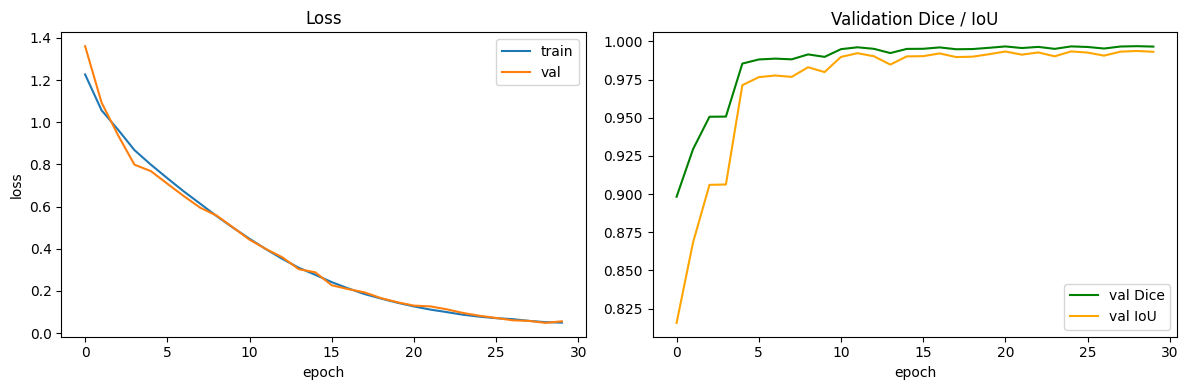

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set(title="Loss", xlabel="epoch", ylabel="loss"); ax[0].legend()
ax[1].plot(hist["val_dice"], label="val Dice", color="green")
ax[1].plot(hist["val_iou"],  label="val IoU",  color="orange")
ax[1].set(title="Validation Dice / IoU", xlabel="epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG / "unet_curves.png", dpi=150); plt.show()

### Input / ground-truth / prediction panels

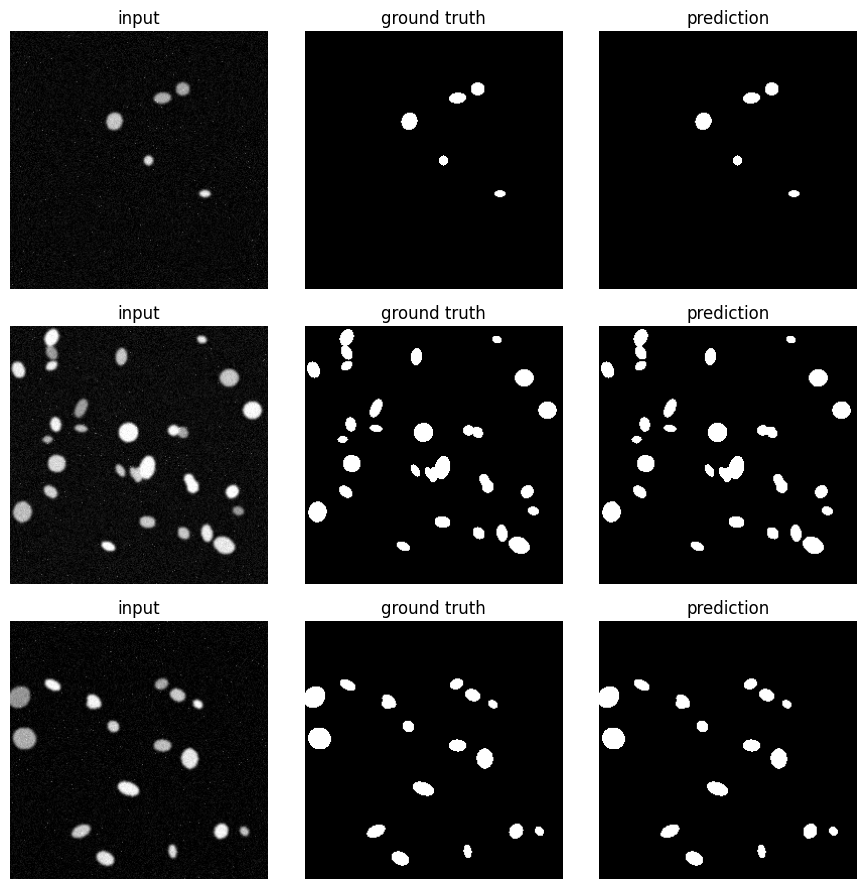

In [30]:
@torch.no_grad()
def show_predictions(model, ds, n=3, save=None):
    model.eval(); n = min(n, len(ds))
    fig, ax = plt.subplots(n, 3, figsize=(9, 3*n)); ax = np.atleast_2d(ax)
    for r in range(n):
        img, msk = ds[r]
        pred = (torch.sigmoid(model(img.unsqueeze(0).to(DEVICE))) > 0.5).float().cpu()
        ax[r,0].imshow(img.squeeze(), cmap="gray");  ax[r,0].set_title("input")
        ax[r,1].imshow(msk.squeeze(), cmap="gray");  ax[r,1].set_title("ground truth")
        ax[r,2].imshow(pred.squeeze(), cmap="gray"); ax[r,2].set_title("prediction")
        for c in range(3): ax[r,c].axis("off")
    plt.tight_layout()
    if save: fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

show_predictions(model, val_ds, n=3, save=FIG / "unet_predictions.png")

### U-Net vs Otsu (question 2)

Compare the U-Net mask against a plain Otsu mask on the same validation images,
scoring both against ground truth. This is the fair head-to-head the report asks
for.

In [31]:
@torch.no_grad()
def unet_mask(model, gray, thr=0.5):
    model.eval()
    x = torch.from_numpy(gray.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(DEVICE)
    return (torch.sigmoid(model(x)).squeeze().cpu().numpy() > thr)

def dice_np(a, b, eps=1e-6):
    a, b = a.astype(bool), b.astype(bool)
    return (2*(a & b).sum() + eps) / (a.sum() + b.sum() + eps)

rows = []
for img, gt in zip(val_imgs, val_masks):
    u = unet_mask(model, img); o = segment_otsu(img)
    rows.append({"unet_dice": dice_np(u, gt > 0.5), "otsu_dice": dice_np(o, gt > 0.5)})
cmp = pd.DataFrame(rows)
print(cmp.mean().round(3))

unet_dice    0.997
otsu_dice    0.972
dtype: float64


## Task 4 — Hybrid pipeline → JSON records → aggregated CSV

For each unseen **test** image: U-Net mask → regionprops table → numeric summary → Qwen2.5-VL structured interpretation → per-image JSON → aggregated CSV. The quantitative measurements remain the source of truth; the model only interprets those numbers and writes a short narrative.


In [32]:
def regularity(s):
    if s.get("n_objects", 0) == 0: return "uncertain"
    sol = s.get("mean_solidity", 0)
    return "regular" if sol >= 0.9 else "mixed" if sol >= 0.75 else "irregular"

def process_one(gray, image_id, unet_model, use_llm=True):
    mask = unet_mask(unet_model, gray) if unet_model is not None else segment_otsu(gray)
    tbl = region_table(gray, mask)
    s = summarise(tbl)
    sent = summary_sentence(s, image_id)

    if use_llm:
        rec = describe_numbers(sent, temperature=0.2)
        narrative = rec.get("narrative", "")
    else:
        rec = {"n_objects": s.get("n_objects", 0),
               "density_class": density_class(s),
               "shape_regularity": regularity(s),
               "quality_flag": "ok" if s.get("n_objects", 0) > 0 else "check",
               "narrative": sent}
        narrative = rec["narrative"]

    return {"image_id": image_id,
            "n_objects": s.get("n_objects", 0),
            "mean_area": round(s.get("mean_area", 0.0), 1),
            "density_class": rec.get("density_class", "uncertain"),
            "shape_regularity": rec.get("shape_regularity", "uncertain"),
            "quality_flag": rec.get("quality_flag", "uncertain"),
            "narrative": str(narrative).strip()[:500]}

# Use the trained U-Net from Task 3 and Qwen2.5-VL for the numerical interpretation.
# The assignment requires the LLM component, so do not silently fall back here.
load_qwen_model()
records = []
for gray, image_id in zip(test_imgs, test_ids):
    rec = process_one(gray, image_id, model, use_llm=True)
    records.append(rec)
    with open(REC / f"{image_id}.json", "w") as f:
        json.dump(rec, f, indent=2)

records_df = pd.DataFrame(records)
records_df.to_csv(REC / "aggregated_records.csv", index=False)
print("Saved", len(records_df), "per-image JSON records and aggregated_records.csv")
records_df[["image_id","n_objects","density_class","shape_regularity","quality_flag"]]


Saved 12 per-image JSON records and aggregated_records.csv


,image_id,n_objects,density_class,shape_regularity,quality_flag
0,test_000,8,sparse,irregular,check
1,test_001,14,dense,irregular,check
2,test_002,26,dense,irregular,check
3,test_003,19,dense,irregular,check
4,test_004,43,dense,irregular,check
5,test_005,16,dense,irregular,check
6,test_006,8,dense,irregular,check
7,test_007,23,dense,irregular,check
8,test_008,23,dense,uncertain,check
9,test_009,21,dense,irregular,check


### Score the pipeline against the ground-truth answer key

`metadata.csv` has the true `n_objects` and `density` per image, so we can check
how close the pipeline's counts are — a concrete, quantitative evaluation for
the report rather than just eyeballing.

In [33]:
if meta is not None:
    truth = meta.set_index("image_id")
    check = records_df.set_index("image_id").join(
        truth[["n_objects", "density"]], rsuffix="_true")
    check["count_error"] = check["n_objects"] - check["n_objects_true"]
    print(check[["n_objects", "n_objects_true", "count_error",
                 "density_class", "density"]].to_string())
    mae = check["count_error"].abs().mean()
    print(f"\nMean absolute object-count error: {mae:.2f}")
else:
    print("metadata.csv not found — skipping ground-truth scoring.")

          n_objects  n_objects_true  count_error density_class    density
image_id                                                                 
test_000          8               8            0        sparse     sparse
test_001         14              19           -5         dense     normal
test_002         26              31           -5         dense     normal
test_003         19              21           -2         dense     normal
test_004         43              75          -32         dense      dense
test_005         16              49          -33         dense  clustered
test_006          8               8            0         dense     sparse
test_007         23              30           -7         dense     normal
test_008         23              28           -5         dense     normal
test_009         21              24           -3         dense     normal
test_010         38              78          -40         dense      dense
test_011         20              30   